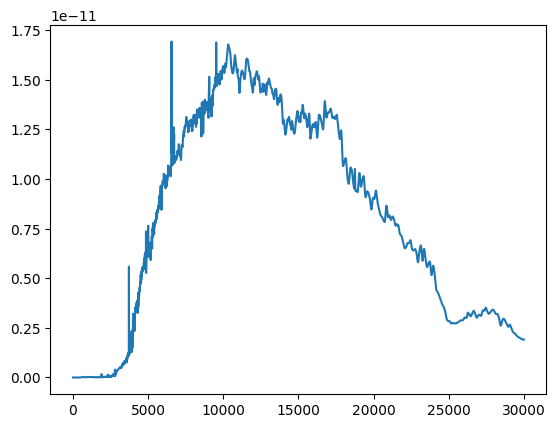

In [16]:
import numpy as np
wave, flux = np.loadtxt("default_sed1.dat", unpack=True)  # Update path as needed
import matplotlib.pyplot as plt
plt.plot(wave,flux)


In [43]:
from sedpy.observate import load_filters, getSED
filters = load_filters(['hsc_g', 'hsc_r', 'hsc_i', 'hsc_z', 'hsc_y'])
fn=[f.name for f in filters]

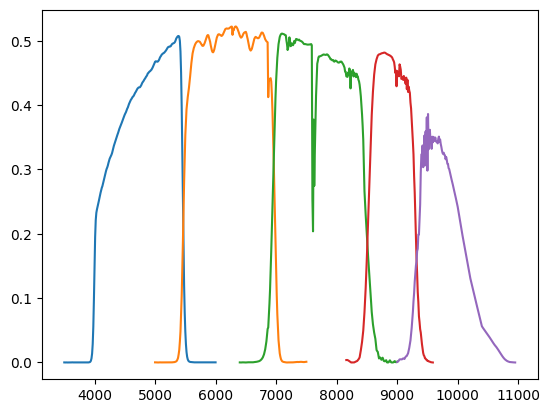

In [3]:
for i in filters:
    plt.plot(i.wavelength, i.transmission)

In [36]:
%matplotlib inline
import numpy as np
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
from scipy.interpolate import InterpolatedUnivariateSpline, interp1d
from scipy.special import erfc
import pandas as pd
import seaborn as sns 
import itertools

In [37]:
# This is the prior HDFN prior from Benitez 2000, adapted from the BPZ code.
# This could be replaced with any redshift, magnitude, and type distribution.
def bpz_prior(z, m, nt):
    nz = len(z)
    momin_hdf = 20.
    if m>32.: m = 32.
    if m<20.: m = 20.    
    # nt Templates = nell Elliptical + nsp Spiral + nSB starburst
      # nt is a list of 3 values
    nell, nsp, nsb = nt
    nn = nell, nsp, nsb
    nt = sum(nn)
    # See Table 1 of Benitez00
    a  = 2.465,  1.806,  0.906
    zo = 0.431,  0.390,  0.0626
    km = 0.0913, 0.0636, 0.123
    k_t= 0.450,  0.147
    a  = np.repeat(a, nn)
    zo = np.repeat(zo, nn)
    km = np.repeat(km, nn)
    k_t= np.repeat(k_t, nn[:2])
    # Fractions expected at m = 20: 35% E/S0, 50% Spiral, 15% Irr
    fo_t = 0.35, 0.5
    fo_t = fo_t / np.array(nn[:2])
    fo_t = np.repeat(fo_t, nn[:2])
    dm = m-momin_hdf
    zmt = np.clip(zo+km*dm,0.01,15.)
    zmt_at_a = zmt**(a)
    zt_at_a = np.power.outer(z,a)
    #Morphological fractions
    nellsp = nell + nsp
    f_t = np.zeros((len(a),),float)
    f_t[:nellsp] = fo_t*np.exp(-k_t*dm)
    f_t[nellsp:] = (1.-np.add.reduce(f_t[:nellsp]))/float(nsb)
    #Formula: zm=zo+km*(m_m_min)  and  p(z|T,m)=(z**a)*exp(-(z/zm)**a)
    p_i = zt_at_a[:nz,:nt]*np.exp(-np.clip(zt_at_a[:nz,:nt]/zmt_at_a[:nt],0.,700.))
    #This eliminates the very low level tails of the priors
    norm = np.add.reduce(p_i[:nz,:nt],0)
    p_i[:nz,:nt] = np.where(np.less(p_i[:nz,:nt]/norm[:nt],1e-2/float(nz)),
              0.,p_i[:nz,:nt]/norm[:nt])
    norm = np.add.reduce(p_i[:nz,:nt],0)
    p_i[:nz,:nt] = p_i[:nz,:nt]/norm[:nt]*f_t[:nt]
    return p_i

In [38]:
from glob import glob
l=glob('eazy*')
for i in l:
    wave, flux = np.loadtxt(i, unpack=True)
    flux /= np.max(flux)
    blue = (wave > 3750) & (wave < 3950)
    red  = (wave > 4050) & (wave < 4250)
    D4000 = flux[red].mean() / flux[blue].mean()
    print(i)
    print(D4000)


eazy_v1.0_sed1.dat
1.6722058727345785
eazy_v1.0_sed2.dat
0.9322811605872342
eazy_v1.0_sed3.dat
1.1484458432345976
eazy_v1.0_sed4.dat
1.4681395033769324
eazy_v1.0_sed5.dat
1.7135179503156674
eazy_v1.0_sed6.dat
1.2131673386579749


C:\Users\pranav\AppData\Local\Temp\ipykernel_28980\3895753617.py:38: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(p, labels=names)


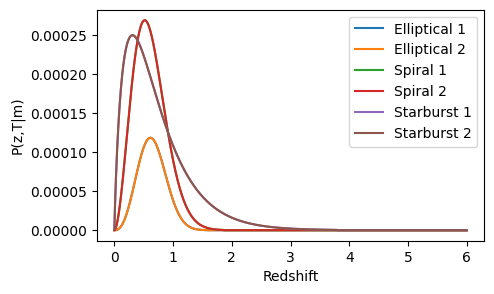

In [39]:
z_grid_binsize = 0.001
z_grid_edges = np.arange(0.0, 6.0, z_grid_binsize)
z_grid = (z_grid_edges[1:] + z_grid_edges[:-1])/2.

# Just some boolean indexing of templates used. Needed later for some BPZ fcts.
selectedtemplates = np.repeat(False, 6)

# Using all templates
templatetypesnb = (2, 2, 2) # nb of ellipticals, spirals, and starburst used in the 8-template library.
selectedtemplates[:] = True

# Uncomment that to use three templates using
#templatetypesnb = (1,1,1) #(1,2,8-3) 
#selectedtemplates[0:1] = True
nt = sum(templatetypesnb)

ellipticals = ['eazy_v1.0_sed2.dat','eazy_v1.0_sed3.dat'][0:templatetypesnb[0]]
spirals = ['eazy_v1.0_sed6.dat','eazy_v1.0_sed4.dat'][0:templatetypesnb[1]]
irregulars =['eazy_v1.0_sed1.dat','eazy_v1.0_sed5.dat'][0:templatetypesnb[2]]
template_names = [nm.replace('eazy_v1.0_','') for nm in ellipticals+spirals+irregulars]
template_names = [nm.replace('.dat','') for nm in template_names]
# Use the p(z,t,m) distribution defined above
m = 22.0 # some reference magnitude
p_z__t_m = bpz_prior(z_grid, m, templatetypesnb)

# Convenient function for template names
def mknames(nt):
    return ['Elliptical '+str(i+1) for i in range(nt[0])] \
    + ['Spiral '+str(i+1) for i in range(nt[1])]\
    + ['Starburst '+str(i+1) for i in range(nt[2])]
names = mknames(templatetypesnb)

# Plot the priors for these templates
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
p = ax.plot(z_grid, p_z__t_m)
plt.xlabel('Redshift')
plt.ylabel('P(z,T|m)')
ax.legend(p, labels=names)

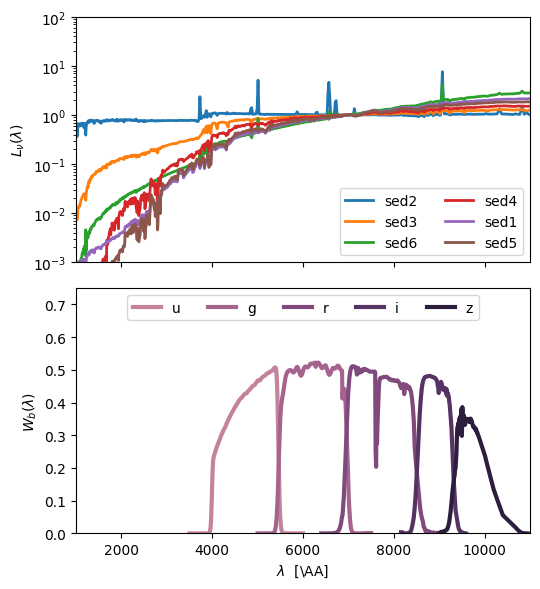

In [52]:
# Load and plot the templates and filters
palette = itertools.cycle(sns.color_palette())
fig, axs = plt.subplots(2, 1, figsize=(5.5, 6), sharex=True)
for i, template_name in enumerate(template_names):
    data = np.genfromtxt('eazy_v1.0_'+template_name+'.dat')
    wavelength, template_sed = data[:,0], data[:,1] * data[:,0]**2
    fnorm = np.interp(7e3, wavelength, template_sed)
    axs[0].plot(wavelength, (template_sed / fnorm), label=template_names[i], 
                c=next(palette), lw=2)
axs[0].legend(loc='lower right', ncol=2)
axs[0].set_ylabel(r'$L_\nu(\lambda)$')
axs[0].set_yscale('log')
axs[0].set_ylim([1e-3, 1e2])

palette = itertools.cycle(sns.cubehelix_palette(5, light=0.6))
filters = [np.genfromtxt(band+'.dat') for band in fn]
for f, data in zip(ab_filters, filters):
    axs[1].plot(data[:,0], data[:,1], label=f, c=next(palette), lw=3)
axs[1].set_xlim([1e3, 1.1e4])
axs[1].set_ylim([0, 0.75])
axs[1].set_xlabel(r'$\lambda$  [\AA]')
axs[1].set_ylabel(r'$W_b(\lambda)$')
axs[1].legend(loc='upper center', ncol=5)
fig.tight_layout()

(0.0, 0.8)

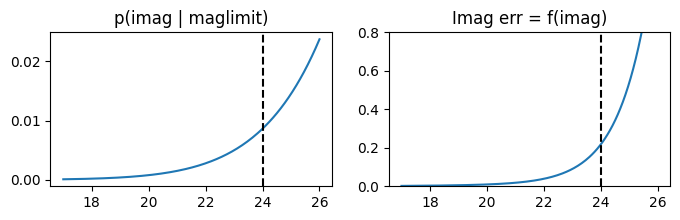

In [53]:
maglim = 24  # magnitude limit
off = 1.  # some offset
imag_grid = np.linspace(17, 26, num=200)  # grid for i magnitude
imagerr_grid = np.linspace(0, 0.4, num=200)  # grid for i magnitude error

# some parameters for prob(imagnitude)
alpha = 15.0 
beta = 2

# prob(imagnitude) distribution
p_imag = imag_grid**alpha*np.exp(-(imag_grid/(maglim-off))**beta)
p_imag /= p_imag.sum()

# imag errir distribution as function of mag limit, as in Rykoff et al
def imag_err(m, mlim):
    a, b = 4.56, 1
    k = 1
    sigmadet = 5
    teff = np.exp(a + b * (mlim - 21.))
    F = 10**(-0.4*(m-22.5))
    Flim = 10**(-0.4*(mlim-22.5))
    Fnoise = (Flim/sigmadet)**2 * k * teff - Flim
    return 2.5/np.log(10) * np.sqrt( (1 + Fnoise/F) / (F*k*teff))
    
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(imag_grid, p_imag)
axs[0].axvline(maglim, c='k', ls='dashed')
axs[0].set_title('p(imag | maglimit)')
axs[1].plot(imag_grid, imag_err(imag_grid, maglim))
axs[1].axvline(maglim, c='k', ls='dashed')
axs[1].set_title('Imag err = f(imag)')
axs[1].set_ylim([0, 0.8])

In [55]:
def draw_mag(nobj, imag_grid, p_imag):
    imag_grid_binsize = (imag_grid[1] - imag_grid[0])
    imag_grid_mid = (imag_grid[1:] + imag_grid[:-1])/2.0
    p_cumul = np.cumsum(p_imag) / np.sum(p_imag)
    pos = np.random.uniform(0.0, 1.0, size=nobj)
    res = np.zeros(nobj, dtype=int)
    for i in range(imag_grid.size-1):
        cond = np.logical_and(pos > p_cumul[i], pos <= p_cumul[i+1])
        res[cond] = i 
    return imag_grid_mid[res] + (np.random.rand(nobj) - 0.5)*imag_grid_binsize
    
# Draw types + redshifts for given z_grid, i magnitudes, and which types are used. 
def draw_types_and_redshifts(nobj, z_grid, imags, templatetypesnb):
    types = np.zeros(nobj, dtype=int)
    z_grid_binsize = (z_grid[1]-z_grid[0])
    z_grid_mid = (z_grid[1:]+z_grid[:-1])/2.0
    redshifts = np.zeros(nobj, dtype=float)
    redshiftlocs = np.zeros(nobj, dtype=int)
    nt = np.sum(templatetypesnb)    
    for ii in range(nobj):
        pos = np.random.uniform(0.0, 1.0, size=2)
        p_ztm = bpz_prior(z_grid, imags[ii], templatetypesnb)
        p_tm = p_ztm.sum(axis=0)
        p_tm_cumul = np.cumsum(p_tm) / np.sum(p_tm)
        for i in range(p_tm_cumul.size-1):
            if pos[0] > p_tm_cumul[i] and pos[0] <= p_tm_cumul[i+1]:
                types[ii] = i + 1
                break
        p_ztm_cumul = np.cumsum(p_ztm[:,types[ii]]) / np.sum(p_ztm[:,types[ii]])
        for i in range(p_ztm_cumul.size-1):
            if pos[1] > p_ztm_cumul[i] and pos[1] <= p_ztm_cumul[i+1]:
                redshiftlocs[ii] = i + 1
                redshifts[ii] = z_grid[i + 1] + (np.random.rand(1)-0.5)*z_grid_binsize
                break
    return redshifts, redshiftlocs, types

In [56]:
nobj = 100000
imags = draw_mag(nobj, imag_grid, p_imag)
imagerrs = imag_err(imags, maglim) 
imagswitherr_all = imags + imagerrs*np.random.randn(nobj)
ind = (1./imagerrs > 5.) # Doing SNR cut - keep galaxies detected at 5 sigma only
# Change the arrays to keep these objects only
nobj = ind.sum()
imags = imags[ind]
imagerrs = imagerrs[ind]
imagswitherr = imagswitherr_all[ind]
redshifts, redshiftlocs, types = draw_types_and_redshifts(nobj, z_grid, imags, templatetypesnb)

data = np.vstack((redshifts, types, imags)).T

C:\Users\pranav\AppData\Local\Temp\ipykernel_28980\2547703203.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  redshifts[ii] = z_grid[i + 1] + (np.random.rand(1)-0.5)*z_grid_binsize


C:\Users\pranav\AppData\Local\Temp\ipykernel_28980\3783946815.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[3].set_xticklabels(names, rotation=90)


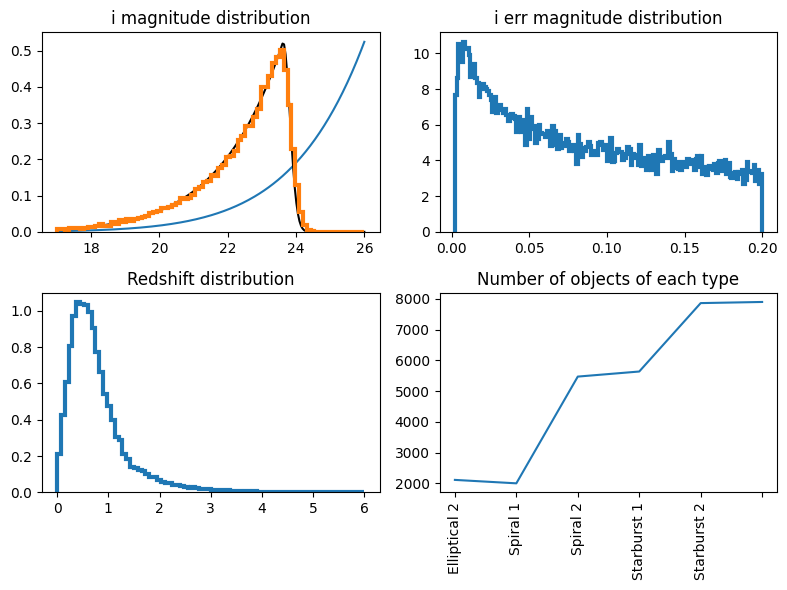

In [59]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.ravel()
detprob = 1*p_imag 
ind = (imag_grid >= maglim - 0.4)
detprob[ind] *= np.exp( -0.5*((imag_grid[ind]-maglim+0.4)/0.2)**2)
#detprob[ind] *= ( 1 - scipy.special.erf((imag_grid[ind]-maglim+0.4)/0.4) )
detprob /= detprob.sum() * (imag_grid[1]-imag_grid[0])
#axs[0].hist(imags, normed=True, range=[imag_grid.min(), imag_grid.max()], bins=180, histtype='step', lw=3)
axs[0].plot(imag_grid, p_imag/np.sum(p_imag)/(imag_grid[1]-imag_grid[0]))
axs[0].plot(imag_grid, detprob, color='k')
axs[0].hist(imagswitherr, density=True, range=[imag_grid.min(), imag_grid.max()], bins=80, histtype='step', lw=3)
axs[0].set_title('i magnitude distribution')
axs[1].hist(imagerrs, density=True, range=[imagerrs.min(), imagerrs.max()], bins=180, histtype='step', lw=3)
axs[1].set_title('i err magnitude distribution')
axs[2].hist(redshifts, density=True, range=[z_grid.min(), z_grid.max()], bins=80, histtype='step', lw=3)
axs[2].set_title('Redshift distribution')
counts = [np.sum(types==i) for i in range(nt)]
axs[3].plot(counts)
axs[3].set_title('Number of objects of each type')
axs[3].set_xticklabels(names, rotation=90)

fig.tight_layout()


In [87]:
nobj = 20000
imags = imags[0:nobj]
imagerrs = imagerrs[0:nobj]
imagswitherr = imagswitherr[0:nobj]
redshifts = redshifts[0:nobj] 
redshiftlocs = redshiftlocs[0:nobj] 
types = types[0:nobj] 

reffilter = 2 # Which one is the reference? i band by default but could be anything.

# Approximate luminosity distance for flat LCDM
def DL(z):
    return np.exp(30.5 * z**0.04 - 21.7)

# We will now use the BPZ routines to load the magnitude-redshift model for each template.
# We'll have interpolated and discretized versions
nf = len(filters)
nz = len(z_grid)
f_mod = np.zeros((nz,nt,nf))*0.
f_mod_interps = np.zeros((nt, nf), dtype=interp1d)
lambdaRef = 4.5e3
for it in range(nt):
    seddata = np.genfromtxt('eazy_v1.0_'+template_names[it] + '.dat')
    seddata[:, 1] *= seddata[:, 0]**2. / 3e18
    ref = np.interp(lambdaRef, seddata[:, 0], seddata[:, 1])
    seddata[:, 1] /= ref
    sed_interp = interp1d(seddata[:, 0], seddata[:, 1], kind='linear', bounds_error=False, fill_value=0.0, assume_sorted=False)
    for jf in range(nf):
        data = np.genfromtxt(fn[jf] + '.dat')
        xf, yf = data[:, 0], data[:, 1]
        yf /= xf  # divide by lambda
        # Only consider range where >1% max
        ind = np.where(yf > 0.01*np.nanmax(yf))[0]
        lambdaMin, lambdaMax = xf[ind[0]], xf[ind[-1]]
        norm = np.trapz(yf[1:], x=xf[1:])
        for iz in range(z_grid.size):
            opz = (z_grid[iz] + 1)
            xf_z = np.linspace(lambdaMin / opz, lambdaMax / opz, num=5000)
            yf_z = interp1d(xf / opz, yf)(xf_z)
            ysed = sed_interp(xf_z)
            f_mod[iz, it, jf] = np.trapz(ysed * yf_z, x=xf_z) / norm
            f_mod[iz, it, jf] *= opz**2. / DL(z_grid[iz])**2. / (4*np.pi)
        f_mod_interps[it, jf] = InterpolatedUnivariateSpline(z_grid, f_mod[:, it, jf])

In [89]:
# f_mod denotes the (discretized or continuous) model magnitude-redshift curves
# Let's now get magnitudes for all the objects we've drawn
f_obs_err = np.zeros((nobj,nf), dtype=float) # magnitude error
f_obs_noerr = np.zeros((nobj,nf), dtype=float) # noiseless magnitude
f_obs = np.zeros((nobj,nf), dtype=float)  # noisy magnitude
#types = np.array(types.astype(int))
for jf in range(nf):
    if jf == reffilter:
        f_obs_err[:,reffilter] = imagerrs * (1 + 0.05* np.random.randn(nobj))
        f_obs[:,reffilter] = imags + f_obs_err[:,reffilter] * np.random.randn(nobj)
        f_obs_noerr[:,reffilter] = imags
    else:
        cmod = np.array([-2.5*np.log10(np.clip(
                        f_mod_interps[types[i],jf](redshifts[i])/f_mod_interps[types[i],reffilter](redshifts[i])
                        ,1e-5,1e5)) for i in range(nobj)])
        f_obs_err[:,jf] = imagerrs * (1 + 0.05* np.random.randn(nobj))
        f_obs[:,jf] = imags + cmod + f_obs_err[:,jf] * np.random.randn(nobj)
        f_obs_noerr[:,jf] = imags + cmod 

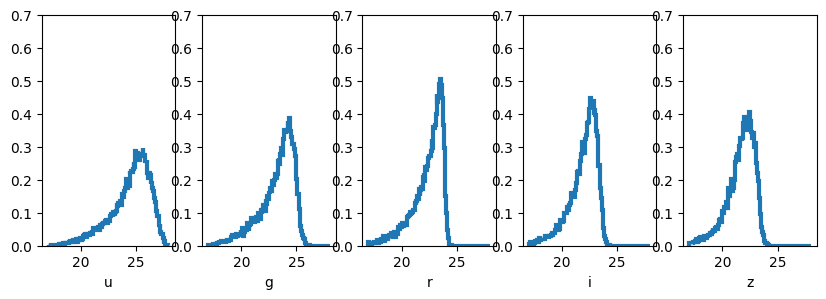

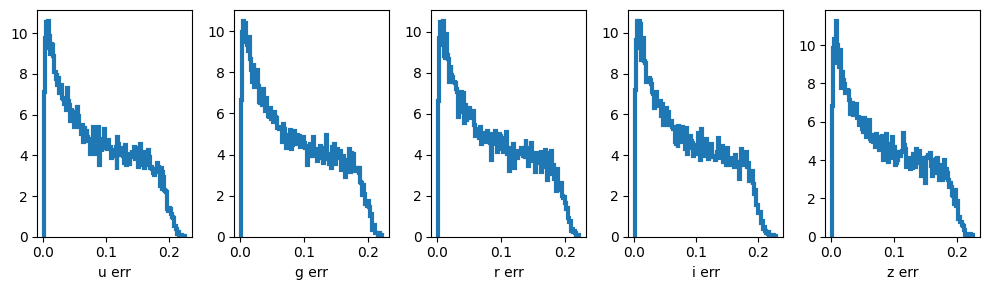

In [90]:
# Let's visualize the magnitudes
fig, axs = plt.subplots(1, nf, figsize=(10,3))
for jf in range(nf):
    axs[jf].hist(f_obs[:,jf], density=True, 
                 range=[imag_grid.min(), imag_grid.max()+2], 
                 bins=150, histtype='step', lw=3)
    axs[jf].set_ylim([0,0.7])
    axs[jf].set_xlabel(filters[jf])
fig, axs = plt.subplots(1, nf, figsize=(10,3))
for jf in range(nf):
    axs[jf].hist(f_obs_err[:,jf], density=True, bins=150, histtype='step', lw=3)
    axs[jf].set_xlabel(filters[jf]+' err')
fig.tight_layout()

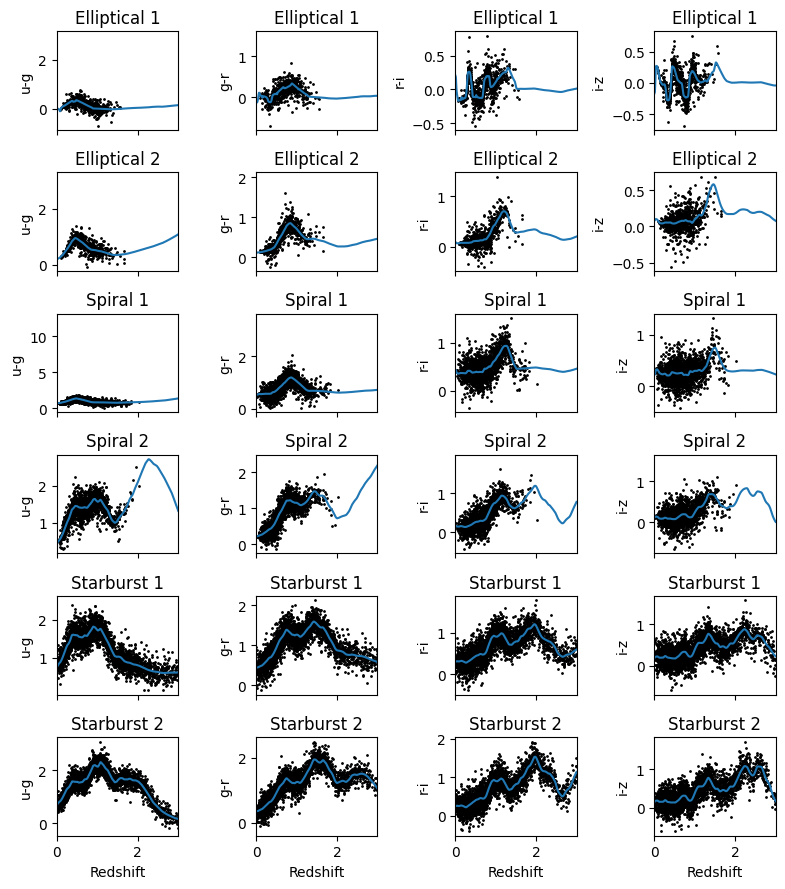

In [93]:
# Let's plot the model and the noisy magnitudes for our mock catalogue
fig, axs = plt.subplots(nt, nf-1, figsize=(8,nt*1.5), sharex=True, sharey=False)
for it in range(nt):
    ind = (types == it)
    for jf in range(nf-1):
        theax = axs[it,jf]
        colour = -2.5*np.log10(np.clip(f_mod[:,it,jf] / f_mod[:,it,jf+1], 1e-5, 1e5))
        colourobj = f_obs[:,jf] - f_obs[:,jf+1]
        p = theax.scatter(redshifts[ind], colourobj[ind], c='k', s=1)
        p = theax.plot(z_grid, colour)
        theax.set_title(names[it])
        theax.set_ylabel(filters[jf]+'-'+filters[jf+1])
for jf in range(nf-1):
    axs[-1,jf].set_xlabel('Redshift')
theax.set_xlim([0,3])
fig.tight_layout()